In [69]:
# importing necessary libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [70]:
#loading dataset
import os
orders_path = os.path.join('..', 'output', 'orders.csv')
if not os.path.exists(orders_path):
    raise FileNotFoundError(f"orders.csv not found at {orders_path}")
orders = pd.read_csv(orders_path)
orders.head()

,order_id,order_date,sku_id,region,payment_type,delivery_days,delivery_status,campaign_applied,order_quantity
0,ORD000000104,0,SKU0002,south,COD,4,DELIVERED,False,1
1,ORD000000103,0,SKU0002,south,COD,3,DELIVERED,False,1
2,ORD000000102,0,SKU0002,south,COD,2,DELIVERED,False,1
3,ORD000000101,0,SKU0002,south,COD,1,DELIVERED,False,1
4,ORD000000100,0,SKU0002,north,PREPAID,5,DELIVERED,False,1


In [71]:
# converting order_date to week and day_of_week
orders["week"] = orders["order_date"] // 7
orders["day_of_week"] = orders["order_date"] % 7


In [72]:
# Weekly aggregation
weekly_demand = (
    orders
    .groupby(["week", "sku_id"], as_index=False)
    .agg(
        weekly_qty=("order_quantity", "sum"),
        campaign_days=("campaign_applied", "sum")
    )
)

weekly_demand["campaign_intensity"] = weekly_demand["campaign_days"] / 7

weekly_demand.sort_values(["sku_id", "week"], inplace=True)
weekly_demand.head()


,week,sku_id,weekly_qty,campaign_days,campaign_intensity
0,0,SKU0001,454,0,0.000000
5,1,SKU0001,1461,786,112.285714
10,2,SKU0001,2273,1380,197.142857
15,3,SKU0001,1301,651,93.000000
20,4,SKU0001,1502,954,136.285714


In [73]:
week_counts = orders.groupby("week")["order_date"].count()
full_weeks = week_counts[week_counts >= 7].index

weekly_demand = weekly_demand[
    weekly_demand["week"].isin(full_weeks)
]


In [74]:
# train/validation split
MAX_WEEk = weekly_demand['week'].max()
SPLIT_WEEk = int(MAX_WEEk * 0.8)

train_df= weekly_demand[weekly_demand['week'] <= SPLIT_WEEk]
val_df= weekly_demand[weekly_demand['week'] > SPLIT_WEEk]
print("Train weeks:", train_df["week"].nunique())
print("Validation weeks:", val_df["week"].nunique())

Train weeks: 84
Validation weeks: 21


In [75]:
# Baseline model: moving average(4 weeks)
from sklearn.metrics import mean_absolute_percentage_error
def baseline_forecast(df, window=4):
    df = df.copy()
    df["baseline"] = (
        df.groupby("sku_id")["weekly_qty"]
          .transform(lambda x: x.rolling(window, min_periods=window).mean())
    )
    return df

baseline_df = baseline_forecast(weekly_demand)

baseline_val = baseline_df[
    (baseline_df["week"] > SPLIT_WEEk) &
    (~baseline_df["baseline"].isna())
]

print("Baseline validation samples:", len(baseline_val))

baseline_mape = mean_absolute_percentage_error(
    baseline_val["weekly_qty"],
    baseline_val["baseline"]
)

baseline_mape


Baseline validation samples: 105


0.09980326822768613

In [76]:
# Feature Enginerring
def make_features(df):
    df = df.copy()

    for lag in [1, 2, 4]:
        df[f"lag_{lag}"] = (
            df.groupby("sku_id")["weekly_qty"].shift(lag)
        )

    df["week_of_year"] = df["week"] % 52
    df["sin_week"] = np.sin(2 * np.pi * df["week_of_year"] / 52)
    df["cos_week"] = np.cos(2 * np.pi * df["week_of_year"] / 52)

    return df

ml_df = make_features(weekly_demand)
ml_df.dropna(inplace=True)

train_ml = ml_df[ml_df["week"] <= SPLIT_WEEk]
val_ml   = ml_df[ml_df["week"] > SPLIT_WEEk]

FEATURES = [
    "lag_1", "lag_2", "lag_4",
    "campaign_intensity",
    "sin_week", "cos_week"
]

X_train, y_train = train_ml[FEATURES], train_ml["weekly_qty"]
X_val, y_val     = val_ml[FEATURES], val_ml["weekly_qty"]


In [77]:
(
    weekly_demand
    .groupby("sku_id")["week"]
    .count()
    .sort_values()
)


sku_id
SKU0001    105
SKU0002    105
SKU0003    105
SKU0004    105
SKU0005    105
Name: week, dtype: int64

In [78]:
ml_df = make_features(weekly_demand)
ml_df = ml_df.dropna()

train_ml = ml_df[ml_df["week"] <= SPLIT_WEEk]
val_ml   = ml_df[ml_df["week"] > SPLIT_WEEk]

FEATURES = [
    "lag_1", "lag_2", "lag_4",
    "campaign_intensity",
    "sin_week", "cos_week"
]

X_train = train_ml[FEATURES]
y_train = train_ml["weekly_qty"]

X_val = val_ml[FEATURES]
y_val = val_ml["weekly_qty"]

print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))


Train samples: 400
Validation samples: 105


In [79]:
# model training
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

val_ml=val_ml.copy()
val_ml["ml-forecast"] = model.predict(X_val)

ml_mape = mean_absolute_percentage_error(
    y_val,
    val_ml["ml-forecast"]
)

ml_mape

0.13268753804806785

In [80]:
print(f"Baseline MAPE (weekly): {baseline_mape:.3f}")
print(f"ML MAPE (weekly):       {ml_mape:.3f}")

improvement = (baseline_mape - ml_mape) / baseline_mape * 100
print(f"Relative improvement:   {improvement:.1f}%")


Baseline MAPE (weekly): 0.100
ML MAPE (weekly):       0.133
Relative improvement:   -32.9%


In [81]:
importances = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

importances


lag_2                 0.623828
campaign_intensity    0.284257
lag_1                 0.090485
sin_week              0.000620
lag_4                 0.000515
cos_week              0.000296
dtype: float64

In [82]:
# handle both possible column names created earlier ("ml-forecast" vs "ml_forecast")
if "ml_forecast" in val_ml.columns:
	preds = val_ml["ml_forecast"]
else:
	preds = val_ml["ml-forecast"]

val_ml["residual"] = val_ml["weekly_qty"] - preds

val_ml["residual"].describe()


count    105.000000
mean     -16.560383
std       70.894431
min     -334.545366
25%       -6.907053
50%       -1.694622
75%        5.003276
max       21.803477
Name: residual, dtype: float64

In [83]:
residuals = y_train - model.predict(X_train)

sigma_normal = residuals[train_ml["campaign_intensity"] == 0].std()
sigma_campaign = residuals[train_ml["campaign_intensity"] > 0].std()

def select_sigma(row):
    return sigma_campaign if row["campaign_intensity"] > 0 else sigma_normal

# ensure we have a consistent forecast column name
if "ml_forecast" in val_ml.columns:
    forecast_col = "ml_forecast"
elif "ml-forecast" in val_ml.columns:
    # create a consistent column for downstream usage
    val_ml["ml_forecast"] = val_ml["ml-forecast"]
    forecast_col = "ml_forecast"
else:
    # compute predictions if missing
    val_ml["ml_forecast"] = model.predict(X_val)
    forecast_col = "ml_forecast"

val_ml["sigma"] = val_ml.apply(select_sigma, axis=1)

val_ml["p50"] = val_ml[forecast_col]
val_ml["p90"] = val_ml[forecast_col] + 1.28 * val_ml["sigma"]
val_ml["p10"] = val_ml[forecast_col] - 1.28 * val_ml["sigma"]


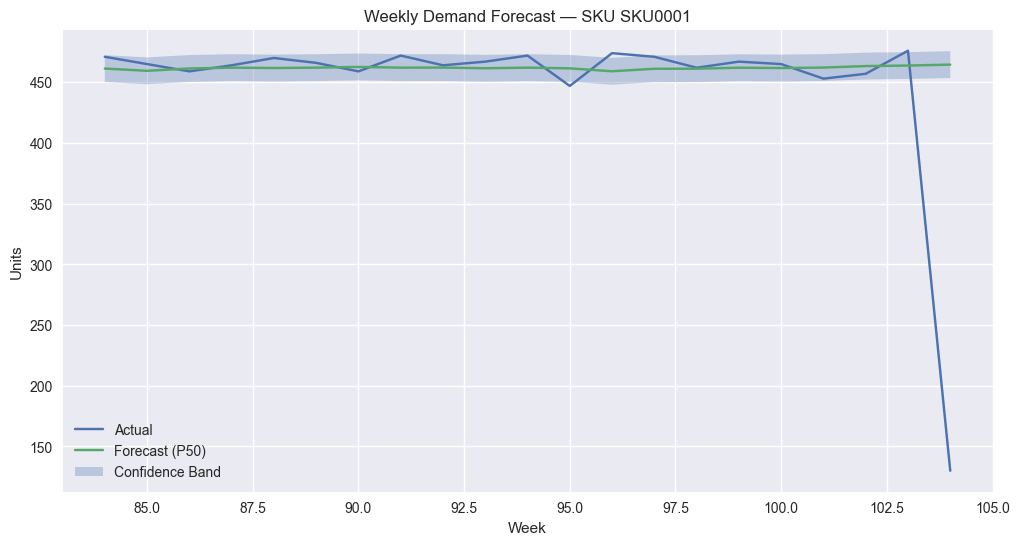

In [84]:
sku = val_ml["sku_id"].iloc[0]
plot_df = val_ml[val_ml["sku_id"] == sku]

plt.figure(figsize=(12,6))
plt.plot(plot_df["week"], plot_df["weekly_qty"], label="Actual")
plt.plot(plot_df["week"], plot_df["p50"], label="Forecast (P50)")
plt.fill_between(
    plot_df["week"],
    plot_df["p10"],
    plot_df["p90"],
    alpha=0.3,
    label="Confidence Band"
)

plt.title(f"Weekly Demand Forecast — SKU {sku}")
plt.xlabel("Week")
plt.ylabel("Units")
plt.legend()
plt.show()
